# Antisense transcription calling
June 9, 2025

Examine the non-sense transcription for various windows of the genome to motivate the need/procedure for calling non-sense transcripts that may be cell cycle-regulated.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [216]:
from src.sgd import read_sgd_genes, read_nondubious_genes_dataset, load_origins_sgd
from src.orf_plotter import load_default_orf_plotter

orf_plotter = load_default_orf_plotter()


In [259]:
chrom = 16

In [420]:
# Load the RNA_seq for chromosome 1, and compute pileup for plotting
from src.timer import Timer
from src.read_bam import read_rna_bam, get_rna_seq_filepaths_df

rna_filepaths_df = get_rna_seq_filepaths_df().set_index(['replicate', 'time'])

def load_all_chrom_reads(rna_filepaths_df, replicate, chrom):
    timer = Timer()

    # Load the first time point
    all_chrom_reads_arr = []
    i = 0
    replicate_filepaths = rna_filepaths_df.loc[replicate]
    for timepoint, row in replicate_filepaths.iterrows():
        time_rna_reads = read_rna_bam(row.full_path)
        single_chrom_reads = time_rna_reads[time_rna_reads['chr'] == chrom].copy()
        single_chrom_reads['sample'] = timepoint
        all_chrom_reads_arr.append(single_chrom_reads)
        timer.print_time(f"{i}/{len(replicate_filepaths)}")
        i += 1

        # Conserve memory
        del time_rna_reads

    all_chrom_reads = pd.concat(all_chrom_reads_arr)
    return all_chrom_reads

all_chrom_reads_rep1 = load_all_chrom_reads(rna_filepaths_df, 1, chrom)
all_chrom_reads_rep2 = load_all_chrom_reads(rna_filepaths_df, 2, chrom)

0/14 - 00:01:21.234
1/14 - 00:02:20.266
2/14 - 00:03:45.623
3/14 - 00:04:58.029
4/14 - 00:06:09.859
5/14 - 00:07:31.383
6/14 - 00:08:12.973
7/14 - 00:10:22.747
8/14 - 00:11:34.499
9/14 - 00:12:58.773
10/14 - 00:14:32.843
11/14 - 00:16:02.392
12/14 - 00:17:30.929
13/14 - 00:19:00.060


In [1041]:
from src.transcript_boundary_caller import AntisenseTranscriptCaller
from src.timer import Timer

timer = Timer()

chrom = 16
caller = AntisenseTranscriptCaller(
    chromosome=chrom,
    min_length=80,                      # Minimum transcript length
    max_gap=120,                         # Maximum gap to merge regions
    timer=timer
)


In [1042]:
caller.load_pileup_from_bam(all_chrom_reads_rep1, all_chrom_reads_rep2,
    chrom_len, smooth=True)

results_df = caller.detect_transcript_boundaries(strand='both')
results_df = caller.annotate_transcript_gene_overlap() # Assign to gene annotations
print(f"Detected {len(results_df)} transcripts for chromosome {chrom}")

Starting pileup computation for chromosome 16 - 00:00:00.000
Completed pileup computation and replicate averaging - 00:00:52.988


In [1044]:
from src.transcript_boundary_visualizer import AntisenseTranscriptVisualizer

visualizer = AntisenseTranscriptVisualizer(
    transcript_caller=caller,
    orf_plotter=orf_plotter,
)


In [1078]:
parent_dir = '/Users/trung/Research/_archive/data/bam/cell_cycle/rna/'

for i, row in rna_filepaths_df.iterrows():
    print(row.full_path.replace(parent_dir, ''))


replicate_1/DMAH1_RNA_rep1_0_min.bam
replicate_1/DMAH2_RNA_rep1_10_min.bam
replicate_1/DMAH3_RNA_rep1_20_min.bam
replicate_1/DMAH4_RNA_rep1_30_min.bam
replicate_1/DMAH5_RNA_rep1_40_min.bam
replicate_1/DMAH6_RNA_rep1_50_min.bam
replicate_1/DMAH7_RNA_rep1_60_min.bam
replicate_1/DMAH8_RNA_rep1_70_min.bam
replicate_1/DMAH9_RNA_rep1_80_min.bam
replicate_1/DMAH10_RNA_rep1_90_min.bam
replicate_1/DMAH31_RNA_rep1_100_min.bam
replicate_1/DMAH32_RNA_rep1_110_min.bam
replicate_1/DMAH33_RNA_rep1_120_min.bam
replicate_1/DMAH34_RNA_rep1_130_min.bam
replicate_1/DMAH35_RNA_rep1_140_min.bam
replicate_1/DMAH36_RNA_rep1_150_min.bam
replicate_2/DMAH100_RNA_rep2_0_min.bam
replicate_2/DMAH101_RNA_rep2_10_min.bam
replicate_2/DMAH102_RNA_rep2_20_min.bam
replicate_2/DMAH103_RNA_rep2_30_min.bam
replicate_2/DMAH104_RNA_rep2_40_min.bam
replicate_2/DMAH105_RNA_rep2_50_min.bam
replicate_2/DMAH106_RNA_rep2_60_min.bam
replicate_2/DMAH107_RNA_rep2_70_min.bam
replicate_2/DMAH108_RNA_rep2_80_min.bam
replicate_2/DMAH109_R

In [ ]:
from src.figure_configs import save_figure_for_paper
from src.utils import mkdir_safe

output_directory = 'output/draft4_run/'
save_dir =  f'{output_directory}/antisense_calling'
mkdir_safe(save_dir)

results_df.to_csv(f"{save_dir}/called_transcripts_chr{chrom}.csv", index=False)



Saved figure to: output/draft4_run//antisense_calling/distribution_chr16.png


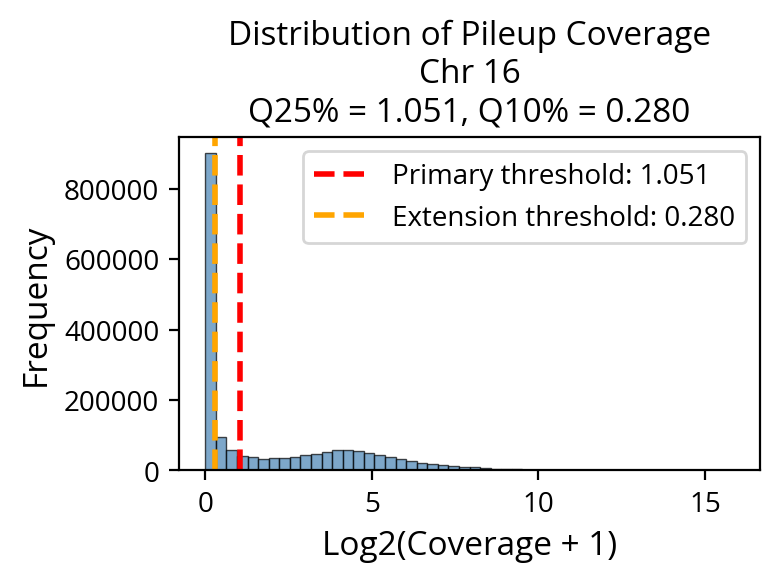

In [1072]:
# 1. Plot threshold distribution to validate parameter choices
fig1 = visualizer.plot_threshold_distribution()
save_figure_for_paper(f"{save_dir}/distribution_chr{chrom}.png")

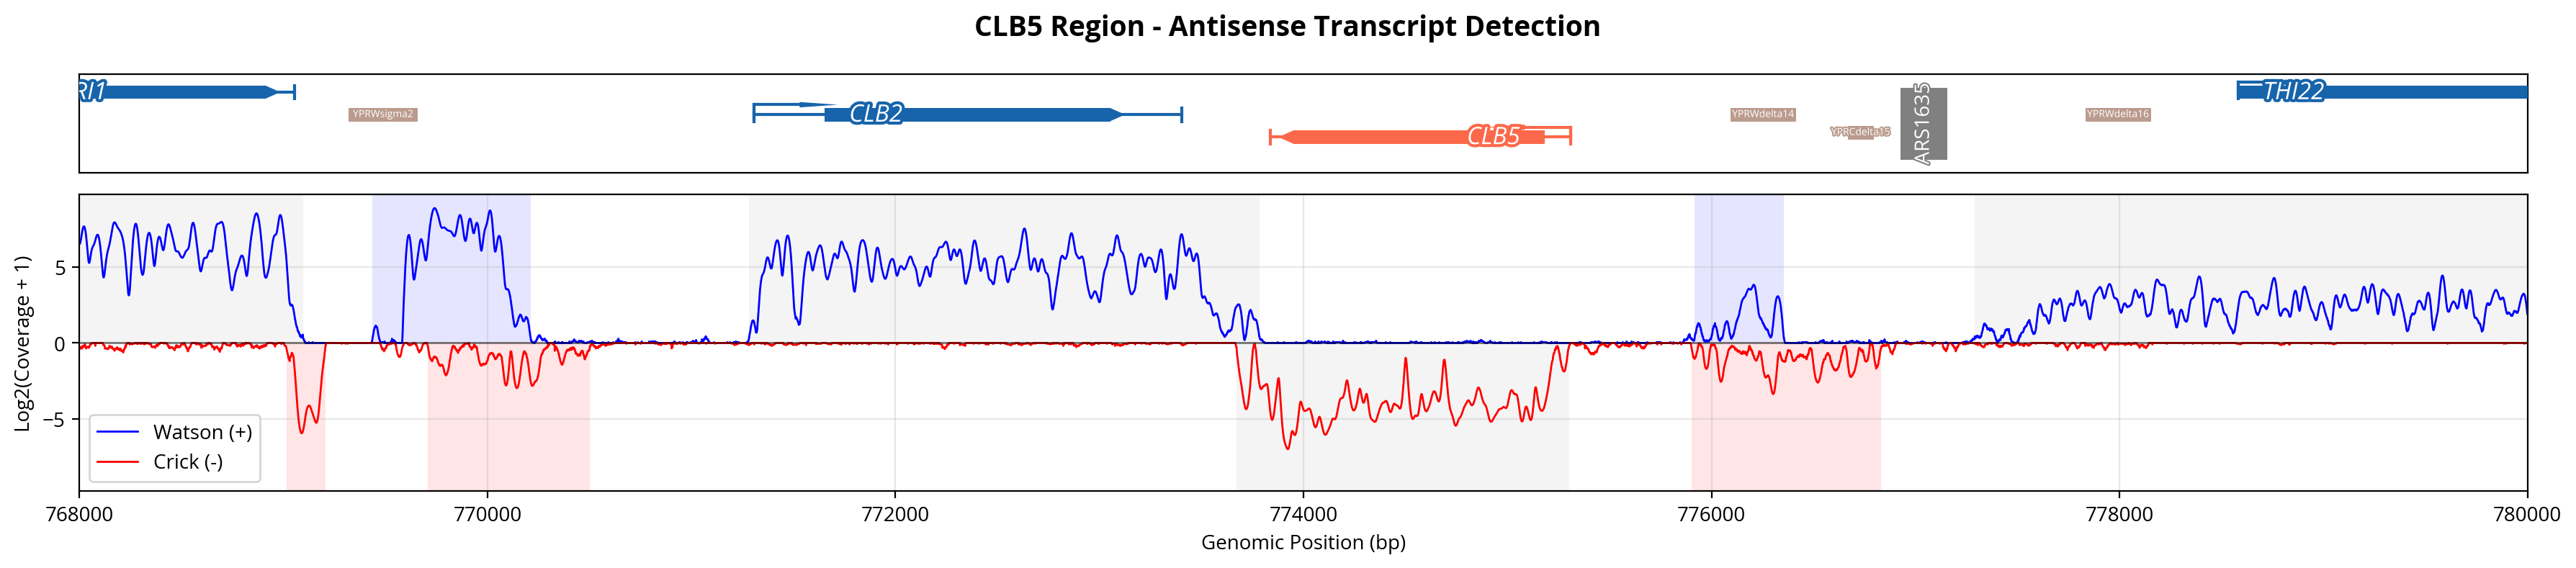

In [1049]:

# 2. Plot region validation (like your CLB5 region)
clb5_region = (768000, 780000)  # Example coordinates
fig2 = visualizer.plot_region_validation(
    span=clb5_region,
    show_orf_annotations=True,
    show_transcript_boundaries=True,
    title="CLB5 Region - Antisense Transcript Detection"
)


In [1057]:
from pipeline.run_pipeline import WINDOWS_ALL_10K_PATH

all_windows_10k = pd.read_csv(WINDOWS_ALL_10K_PATH)

In [1064]:
all_windows_10k[(all_windows_10k.chr == 16) & (all_windows_10k.start == 770000)]

,chr,start,end
1198,16,770000,780000


Creating directory: output/draft4_run//antisense_calling...Directory exists. Skipping.
